In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# Load the npz file
data = np.load("20260204_snaillm_onetone_fluxsweep.npz")

freq = data["freq_GHz"]            # shape: (47, 5001)
current = data["current_uA"].flatten()  # shape: (47,)
amp_dB = data["y_amp_dBfit"]       # shape: (47, 5001)

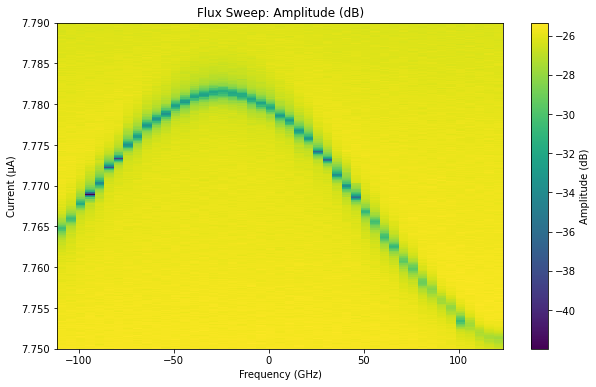

In [26]:
# Make heatmap
plt.figure(figsize=(10,6))
plt.pcolormesh(current, freq[0], amp_dB.T, shading='auto', cmap='viridis')  
# Note: freq[0] since freq is 2D (47,5001) – take first row
plt.xlabel("Frequency (GHz)")
plt.ylabel("Current (µA)")
plt.title("Flux Sweep: Amplitude (dB)")
plt.colorbar(label="Amplitude (dB)")
plt.show()

In [21]:
def cos_func(x, A, C, m, phi):
    return A * np.cos(m * x + phi) + C

def gaussian(x, A, C, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + C

In [73]:
# plt.plot(freq[0], gaussian(freq[0], np.max(amp_dB[0]) - np.min(amp_dB[0]), np.min(amp_dB[0]), 7.77, 0.0005))

In [22]:
res_list = []
for i, curr in enumerate(current):
    A_initial = np.max(amp_dB[i]) - np.min(amp_dB[i])
    C_initial = np.min(amp_dB[i])
    popt, pcov = curve_fit(gaussian, freq[i], amp_dB[i], p0=[A_initial, C_initial, freq[i][np.argmin(amp_dB[i])], 0.005])
    A, C, mu, sigma = popt
    res_list.append(mu)

IndexError: invalid index to scalar variable.

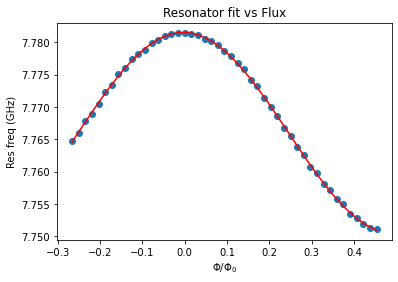

In [ ]:
phase = np.array([np.pi / 160 * (x + 24) for x in current])

m_initial = (np.max(res_list) - np.min(res_list)) * 2
n_initial = np.mean(res_list)

popt, pcov = curve_fit(cos_func, phase, res_list, p0=[m_initial, n_initial, 1, 0])

plt.scatter(phase / (2 * np.pi), res_list)
plt.plot(phase / (2 * np.pi), cos_func(phase, *popt), c='r')

plt.xlabel(r"$\Phi / \Phi_0$")
plt.ylabel("Res freq (GHz)")
plt.title("Resonator fit vs Flux")
plt.show()

In [8]:
specific_current = -10

specific_phase = np.pi / 160 * (specific_current + 24)

print(cos_func(specific_phase, *popt))

7.7808471731277855
